##Contents

0.   Learning Objectives
1.   Tutorial Details
2.   Problem Statement Description
3.   Import Packages
4.   Load and Prepare the Dataset
5.   Peform Exploratory Data Analysis (EDA)
6.   Model Building: Training and Testing
7.   Results and Interpretation
8.   Conclusion
9.   Try it yourself excercise
10.  Summary

#0. Learning Objectives

*   Application of **Logistic Regression** on a public dataset
*   Handle **Categorical** data
*   Playing with the model parameters


#1. Tutorial Details

*   **ML Topic(s) Covered**: Logistic Regression
*   Approximate model training time: Less than 5 min.

#2. Problem Statement Description

*   **Objective**: To build a three class logistic regression classifier to predict the species of the iris flower based on the available four features.
*   **Data Description**: The data set contains information about three different species of iris flowers (setosa, versicolor, and virginica), including their petal and sepal length and width.
*   It contains a total of 150 samples, with 50 samples for each of the three species.
* This is a classification problem with three classes: setosa, versicolor, and virginica.
*   Each sample has four features - Sepal length (in cm), Sepal width (in cm), Petal length (in cm), and Petal width (in cm).
*   More information is available here: https://archive.ics.uci.edu/ml/datasets/iris


Iris Setosa:

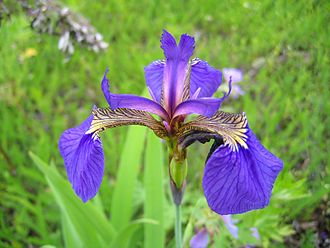

Iris Versicolor:

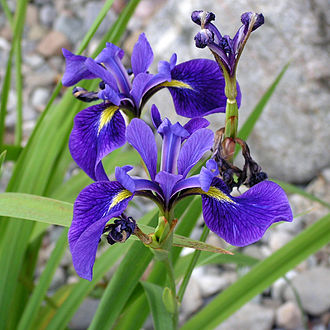

Iris Virginica:

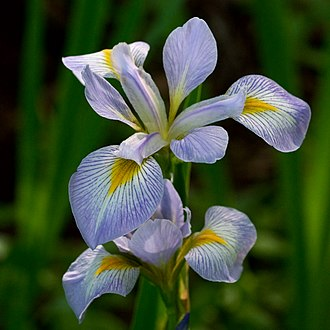

# 3. Import Packages

Package versions

*   pandas==1.4.4
*   numpy==1.22.4
*   matplotlib==3.7.1
*   sklearn==1.2.2

In [1]:
# Pandas contains functions data manipulation and analysis
import pandas as pd

#Numpy combines high-level mathematical operating capabilites with large, multi-dimensional arrays and matrices
import numpy as np

# Matplotlib is a data visualization library containing functions for static, animated, and interactive 2D and 3D plots
import matplotlib.pyplot as plt

# Scikit-learn (sklearn) contains functions of machine learning models, evaluation metrics, helper functions and datasets
import sklearn

# 4. Load and Prepare the Dataset

In [2]:
#Import the data from the provided URL and store it as a DataFrame
data = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data", header=None, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])
#Print
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Here, we have four features followed by one target variable.

In [3]:
#Print the shape of the data
data.shape

(150, 5)

There are 5 columns (4 features and 1 target variable) and 150 rows in the imported data.

In [4]:
#Check information about the data including information about the rows and columns, number of non-null values per column, datatype of each column  and total memory usage.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


*   All features are float values.
*   The target variable is of object (categorical type). This needs to be converted to some numerical value.
*   There is no null value.

Let us check the various categories in the target variable.

In [5]:
np.unique(data['species'])

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

### Handling Categorical Data

Categorical data refers to variables that take on discrete values that represent categories, such as colors, shapes, or types of objects.

It can be **nominal** (no order or ranking among categories; e.g., gender-male/female, hair color-black/brown/green/blue/grey) or **ordinal** (categories have a natural order or ranking; e.g., customer feedback rating 0-10).

One may handle categorical data with one of the following techniques. However, this is not an exhaustive list.


1.  **One-Hot Encoding**: This technique involves creating a new binary feature for each category in the original feature. Each binary feature represents whether the original feature has that category or not.

    * For example, if the original feature is "color" and the possible categories are "red", "green", and "blue", one-hot encoding would create three new binary features: "is_red", "is_green", and "is_blue" to replace the "color" column in the dataset.


2.  **Label Encoding**: This technique involves assigning a unique integer value to each category in the original feature.
    *   For example, if the original feature is "color" and the possible categories are "red", "green", and "blue", label encoding would assign the values 0, 1, and 2 to the categories.

3. **Ordinal Encoding**: This technique is similar to label encoding, but it is used when the categories have a natural order or ranking.
    *   For example, if the original feature is "size" and the possible categories are "small", "medium", and "large", ordinal encoding would assign the values 0, 1, and 2 to the categories, respectively.

    

For our current problem, we will use label encoding.

In [6]:
# Label Encode the target variable
class_dict = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
data['species'] = data['species'].map(class_dict)
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [7]:
features = data.iloc[:, :-1]
predictions = data.iloc[:,-1] #Last column contains the target variable

In [8]:
#Print a fews rows of independent variables
features.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
#Print a fews rows of dependent variables
predictions.head()

0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int64

### Feature Scaling

In [10]:
# Perform feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #Used to perform standardization of the features
features_scaled = scaler.fit_transform(features)
features_scaled = pd.DataFrame(features_scaled, columns = features.columns)
features_scaled.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


The data is split into feature and prediction. Now, it will be further divided into the training and testing data.

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features_scaled, predictions, test_size=0.2, random_state=50, shuffle=True)
#20% of the total data is kept as test data

# 5.   Peform Exploratory Data Analysis (EDA)

In [12]:
Train_data = pd.concat([X_train, y_train], axis = 'columns', #Join along the columns
                       names=[features.columns, 'species'])
Train_data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
125,1.643844,0.337848,1.274550,0.790591,2
98,-0.900681,-1.281972,-0.431421,-0.129720,1
73,0.310998,-0.587764,0.535296,0.001753,1
144,1.038005,0.569251,1.103953,1.710902,2
21,-0.900681,1.494863,-1.284407,-1.050031,0


### Summary Statistics

In [13]:
#Print summary statistics
Train_data.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,120.000000,120.000000,120.000000,120.000000,120.000000
mean,-0.063613,0.008099,-0.028149,-0.023446,1.000000
std,1.000533,0.999773,1.000192,0.997969,0.830106
min,-1.870024,-2.438987,-1.568735,-1.444450,0.000000
25%,-0.900681,-0.587764,-1.284407,-1.181504,0.000000
50%,-0.113090,-0.124958,0.279400,0.133226,1.000000
75%,0.674501,0.627102,0.762759,0.790591,2.000000
max,2.249683,3.114684,1.672610,1.710902,2.000000


Let us also visualize the features in a box plot to check for outliers.

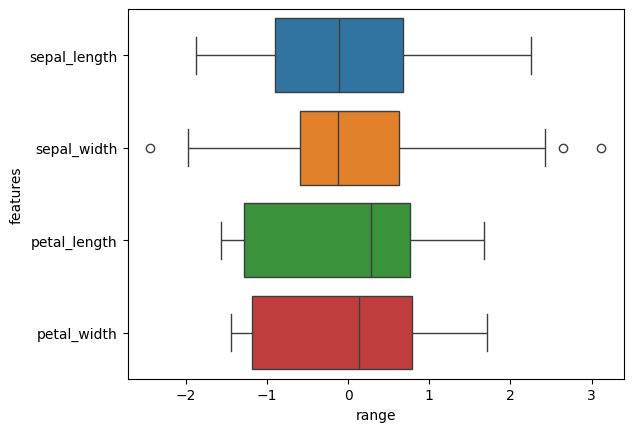

In [14]:
# Seaborn is a data visualization library based on matplotlib
import seaborn as sns

sns.boxplot(data=X_train, orient="h").set(xlabel= 'range', ylabel='features')
plt.show()

The data contains outliers in column 'sepal_width'. Let us validate this further using IQR Rule and extracting outliers.

In [15]:
# Define function to extract outliers using interquartile range (IQR) method
def get_outliers_IQR(X):
    """
    Function to extract outliers using interquartile range (IQR) method.

    Args:
      X (numpy array): The column to find outliers in a dataframe.

    Returns:
      outliers (list): List of oulier (values)
      outlier_indices (list): List of corresponding indices of the outliers
    """
    q1 = np.quantile(X, 0.25) # finding the 1st quartile
    q3 = np.quantile(X, 0.75) #finding the 3rd quartile
    median = np.median(X)

    # find the iqr region
    iqr =q3-q1

    # find upper and lower whiskers
    upper_bound = q3+(1.5*iqr)
    lower_bound = q1-(1.5*iqr)

    #Calculate outliers
    outliers = X[(X <= lower_bound) | (X >= upper_bound)]
    outlier_indices = np.where((X <= lower_bound) | (X >= upper_bound))
    return outliers, outlier_indices[0].tolist()

In order to ensure that we have a copy of the train data before dropping the outliers, we work with a copy of the train dataframe. This helps us avoid the hastle of generating the training data again from the original data.

In [16]:
#Generate a copy of the train dataframe & work with it.
Train_copy = Train_data.copy()
Train_copy.reset_index(drop=True, inplace=True)

#Calling the 'get_outlier function'
outliers, outlier_indices = get_outliers_IQR(Train_copy['sepal_width'].to_numpy())
# Print the outliers and the corresponding indices
print('The outliers in the feature "sepal_width" are: ', outliers)
print('These are available on indexes: ', outlier_indices)

The outliers in the feature "sepal_width" are:  [ 3.11468391 -2.43898725  2.65187798]
These are available on indexes:  [22, 89, 117]


Let us drop these samples.


In [17]:
Train_copy.drop(outlier_indices, inplace=True)
Train_copy.reset_index(drop=True, inplace=True)
Train_copy

,sepal_length,sepal_width,petal_length,petal_width,species
0,1.643844,0.337848,1.274550,0.790591,2
1,-0.900681,-1.281972,-0.431421,-0.129720,1
2,0.310998,-0.587764,0.535296,0.001753,1
3,1.038005,0.569251,1.103953,1.710902,2
4,-0.900681,1.494863,-1.284407,-1.050031,0
...,...,...,...,...,...
112,1.038005,-0.124958,0.819624,1.447956,2
113,0.068662,0.337848,0.592162,0.790591,1
114,0.674501,-0.587764,1.047087,1.316483,2
115,1.643844,1.263460,1.331416,1.710902,2


The three rows corresponding to the outlier samples have been dropped.

In [18]:
Train_data.shape #Originally

(120, 5)

Notice the change in the dimension of the new dataset.

In [19]:
#Update X_train and y_train
X_train = Train_copy.iloc[:, :-1]
y_train = Train_copy.iloc[:,-1]

In [20]:
y_train

0      2
1      1
2      1
3      2
4      0
      ..
112    2
113    1
114    2
115    2
116    2
Name: species, Length: 117, dtype: int64

Let us now plot the box plot again and check if there are any more outliers.

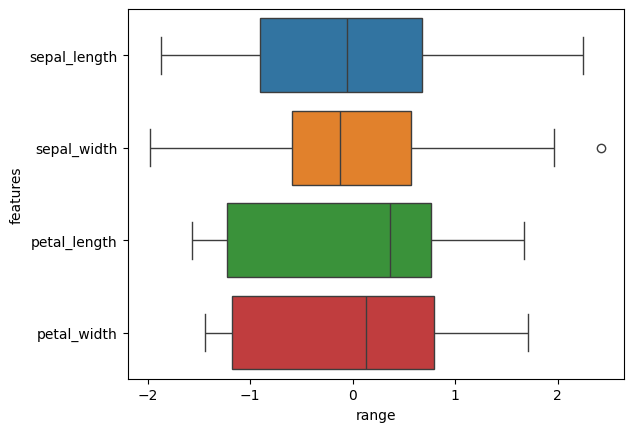

In [21]:
#Plot the box plot
sns.boxplot(data=X_train, orient="h").set(xlabel= 'range', ylabel='features')
plt.show()

The new data of 'sepal_width', still contains an outlier based on the IQR rule. Thus, the outlier dropping process has to be done again to ensure that the data is completely clean.

In [22]:
#Call the 'get_outlier function'
outliers, outlier_indices = get_outliers_IQR(Train_copy['sepal_width'].to_numpy())
# Print the outliers and the corresponding indices
print('The outliers in the feature "sepal_width" are: ', outliers)
print('These are available on indexes: ', outlier_indices)

The outliers in the feature "sepal_width" are:  [2.42047502]
These are available on indexes:  [46]


Let us verify our visual inspections about the outliers.

In [23]:
#Call the 'get_outlier function'
outliers_1, outlier_indices_1 = get_outliers_IQR(Train_copy['sepal_length'].to_numpy())
# Print the outliers and the corresponding indices
print('The outliers in the feature "sepal_width" are: ', outliers_1)
print('These are available on indexes: ', outlier_indices_1)

The outliers in the feature "sepal_width" are:  []
These are available on indexes:  []


Visual inspection has been statistically validated.

In [24]:
#Drop the outlier
Train_copy.drop(outlier_indices, inplace=True)
Train_copy.reset_index(drop=True, inplace=True)
Train_copy

,sepal_length,sepal_width,petal_length,petal_width,species
0,1.643844,0.337848,1.274550,0.790591,2
1,-0.900681,-1.281972,-0.431421,-0.129720,1
2,0.310998,-0.587764,0.535296,0.001753,1
3,1.038005,0.569251,1.103953,1.710902,2
4,-0.900681,1.494863,-1.284407,-1.050031,0
...,...,...,...,...,...
111,1.038005,-0.124958,0.819624,1.447956,2
112,0.068662,0.337848,0.592162,0.790591,1
113,0.674501,-0.587764,1.047087,1.316483,2
114,1.643844,1.263460,1.331416,1.710902,2


In [25]:
#Update X_train and y_train
X_train = Train_copy.iloc[:, :-1]
y_train = Train_copy.iloc[:,-1]

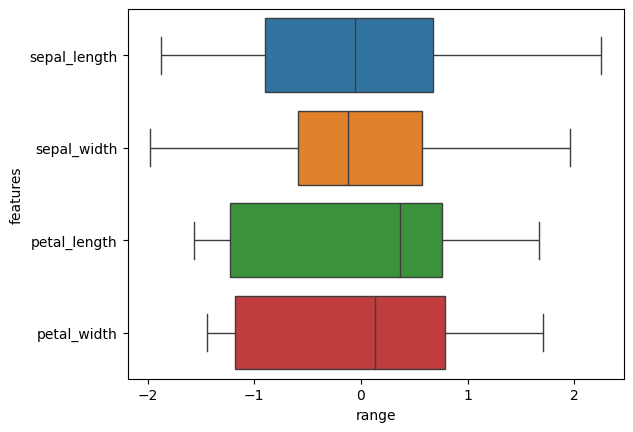

In [26]:
#Plot the box plot again.
sns.boxplot(data=X_train, orient="h").set(xlabel= 'range', ylabel='features')
plt.show()

We see no more outliers. All the outliers have been handled.

**Note**: Handling outliers the second time was our design choice. One may choose to stop at the first iteration itself, or may go on if more outliers appear.

### Class distribution



In [27]:
classes, count = np.unique(y_train, return_counts=True)
count

array([38, 37, 41])

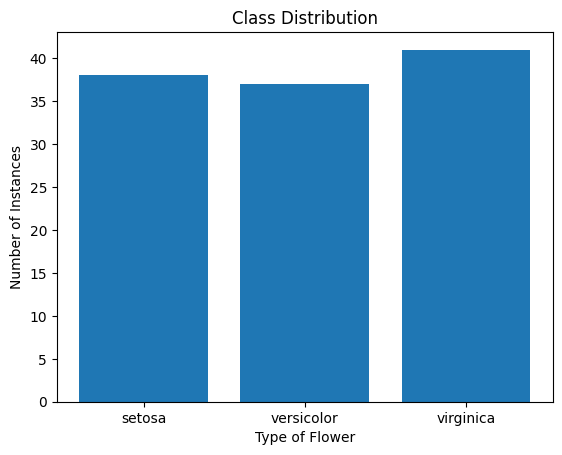

In [28]:
# plot the class distribution
plt.bar(['setosa', 'versicolor', 'virginica'], count)
plt.title('Class Distribution')
plt.xlabel('Type of Flower')
plt.ylabel('Number of Instances')
plt.show()

The data is slightly disbalanced.

### Correlation Analysis

In [29]:
#Perform correlation analysis between numerical features
corr_mat = Train_copy.corr(method ='pearson') #Pearson correlation is used
corr_mat

,sepal_length,sepal_width,petal_length,petal_width,species
sepal_length,1.000000,-0.127313,0.883475,0.825971,0.793662
sepal_width,-0.127313,1.000000,-0.398315,-0.330258,-0.414335
petal_length,0.883475,-0.398315,1.000000,0.959186,0.948916
petal_width,0.825971,-0.330258,0.959186,1.000000,0.955052
species,0.793662,-0.414335,0.948916,0.955052,1.000000


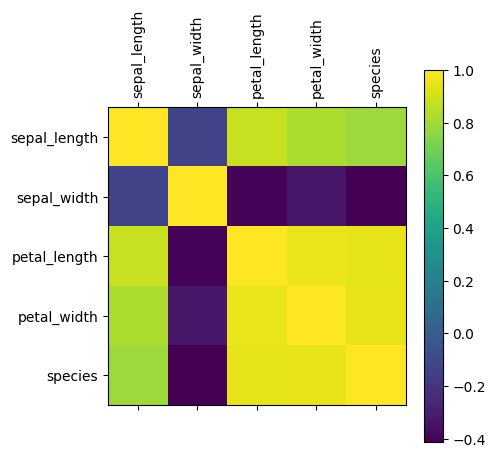

In [30]:
# Visualize the correlation matrix
plt.matshow(corr_mat)
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=90)
plt.yticks(range(len(corr_mat.columns)), corr_mat.columns)
plt.colorbar()
plt.show()

*   The features petal width and length show a stong correlation with the target variable.
*   The feature sepal width is not much correlated with the target variable.
*   The feature sepal length is moderately correlated with the target variable as compared to other features.


### Visualizations

Plot the scatter plot between the dependent varibale and the individual independent variables

[]

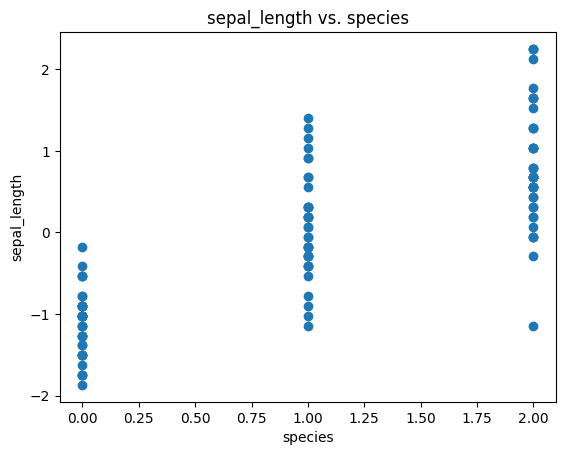

In [31]:
plt.scatter(y_train, X_train['sepal_length'])
plt.title("sepal_length vs. species")
plt.xlabel("species")
plt.ylabel("sepal_length")
plt.plot()

There is an overlap in the sepal length values across species. So, sepal length is not a strong distinguisher between species.

Note: Do not get confused with the negative sepal length. Recall that we did feature scaling.

[]

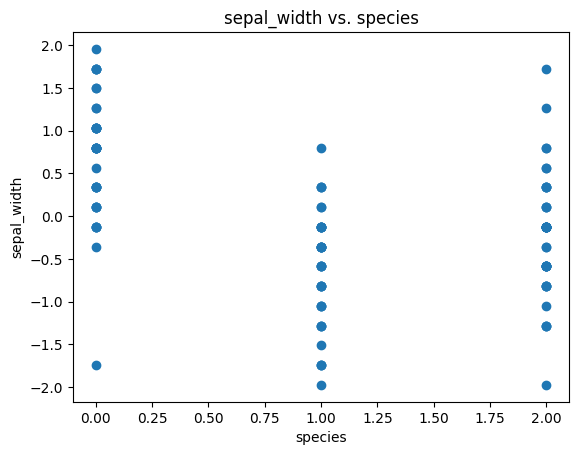

In [32]:
plt.scatter(y_train, X_train['sepal_width'])
plt.title("sepal_width vs. species")
plt.xlabel("species")
plt.ylabel("sepal_width")
plt.plot()

There is an overlap in the sepal width values across species. So, sepal width is also not a strong distinguisher between species.

[]

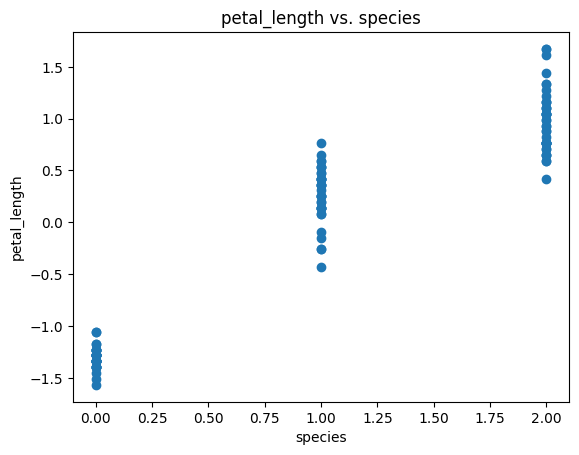

In [33]:
plt.scatter( y_train, X_train['petal_length'])
plt.title("petal_length vs. species")
plt.xlabel("species")
plt.ylabel("petal_length")
plt.plot()

*   We can see that the petal length of the 0th species (setosa) is concentrated between -1 and -1.5. This can be helpful in distiguishing 0th species from the other two.
*   However, the 1st and the 2nd species have overlapping petal_length and therefore, these are indistinguishable using the petal_length feature alone.



[]

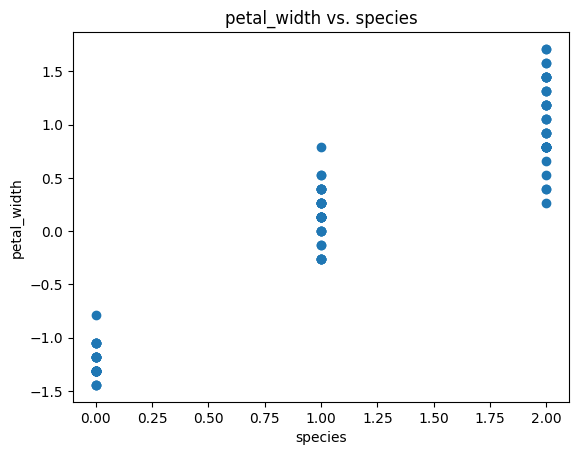

In [34]:
plt.scatter(y_train, X_train['petal_width'])
plt.title("petal_width vs. species")
plt.xlabel("species")
plt.ylabel("petal_width")
plt.plot()

Similar to our observations for petal_width, 0th species is quite distinguishable using petal_width as well.

The above observations from the visualization also mandate us to build an ML-model because merely using individual features we cannot simply distinguish the flower species.

#6.   Model Building: Training and Testing

In [35]:
#Import Logistic Regression class
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0) #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set

*Importance of random state*

One must seed the random state variable wherever applicable. This ensures the reproducibility of the training process. Otherwise, the computer will intrinsically select a random seed every time the function is run.

#7.   Results and Interpretation

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.974
Train confusion matrix: 
 [[38  0  0]
 [ 0 35  2]
 [ 0  1 40]]
Test accuracy:  0.933
Test confusion matrix: 
 [[ 9  0  0]
 [ 0 10  2]
 [ 0  0  9]]



*  The model quite accurately learns class 0; no errors for either train or test predictions. This result is intuitive, as we had seen in the visualizations that both petal_width and petal_length features easily distinguished class 0 from the other two classes.

*   Samples of class 1 is being misclassified as class 2 and vice-versa, by the model in both train and test data. One may work over these examples and improve the model.



# Playing with the Parameters of the model

We have used the Logistic Regression model from sklearn (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). So far, we used the model with default parameters. Let us discuss details about some of the parameters:


*   **penalty** {‘l1’, ‘l2’, ‘elasticnet’, None}, default='l2': This is the regularization type.
*   **C** float, default=1.0 : Inverse of regularization strength; must be a positive float. Smaller values specify stronger regularization.
*   **fit_intercept** bool, default=True: Specifies if a constant (a.k.a. bias or intercept) should be added to the decision function.
*   **class_weight** dict or 'balanced', default=None: Used to specify the weights associated with each class. Its value can be of three types
  * None: All classes have weight=1, regardless of the number of samples of each class.
  * dict: Customised dictionary in the form {class_label: weight} containin weights associated with classes.
  * 'balanced': To give all classes equal weight by giving each sample a weight inversely related to its class's prevalence (proportion of the population) in the training data. This way each class will have equal weight even when the number of samples are different.
* **solver** {‘lbfgs’, ‘liblinear’, ‘newton-cg’, ‘newton-cholesky’, ‘sag’, ‘saga’}, default='lbfgs': Algorithm to use in the optimization problem.
  
  *   **lbfgs**: Utilizes Quasi-Newton methods [https://en.wikipedia.org/wiki/Broyden%E2%80%93Fletcher%E2%80%93Goldfarb%E2%80%93Shanno_algorithm]
  *   **liblinear**: Uses Coordinate descent (CD) algorithm  [https://en.wikipedia.org/wiki/Coordinate_descent]
  *   **newton-cg**: Implementation of Newton's optimization and conjugate gradient (CG) algorithm using quadratic approximation
  *   **newton-cholesky**: Exact implementation of Newton optimization method
  *   **sag**: Implementation of Stochastic Average Gradient descent [Mark Schmidt, Nicolas Le Roux, and Francis Bach: Minimizing Finite Sums with the Stochastic Average Gradient.]
  *   **saga**: Variant of 'sag' [Aaron Defazio, Francis Bach, Simon Lacoste-Julien: SAGA: A Fast Incremental Gradient Method With Support for Non-Strongly Convex Composite Objectives.]

More details available here: https://tminka.github.io/papers/logreg/minka-logreg.pdf (Good resource)


Below table describes the utility for each solver (https://scikit-learn.org/stable/modules/linear_model.html).

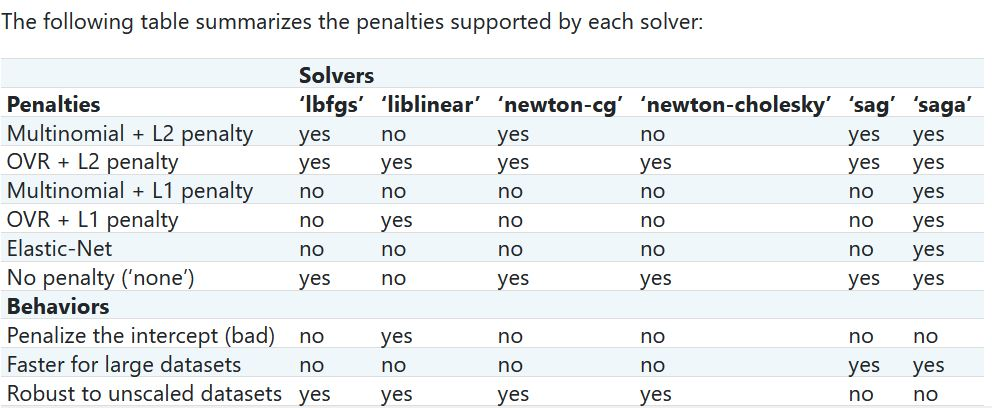

Here, OVR: One-Versus Rest

* **random_state** int, RandomState instance, default=None: Used as the seed to random variables in optimizers.

* **max_iter** int, default=100: Maximum number of iterations taken for the solvers to converge.

*  **l1_ratio** float, default=None: Only used if penalty='elasticnet'. It is the weightage for L1 against L2. It must be between 0 and 1.

*Note*: There are other parameters settings, only relevant ones have been listed here.


Let us check the variations in our model performance by altering the parameters. Let us start with changing the solver.

We select 'saga' for the below reasons:-

*   It is acceptable for all the regularization techniques (None, 'l1', 'l2', or'elastic-net'). So, we can experiment with other parameters with more independence.
*   Ours is a multinomial (multi-class) data. Here, it is a three-class classificaiton.
*   It is fast.
*   The only downside is that it is not robust to unscaled datasets. However, our data is scaled already.



In [37]:
# solver='saga', random_state=0, penalty=None

model = LogisticRegression(solver='saga', random_state=0, penalty=None) #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.983
Train confusion matrix: 
 [[38  0  0]
 [ 0 36  1]
 [ 0  1 40]]
Test accuracy:  0.9
Test confusion matrix: 
 [[9 0 0]
 [0 9 3]
 [0 0 9]]


C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Observations:

*   The divide betwen train and test accuracy has widened. It is a clear case of overfitting. Perhaps, this is where regularization is required.
*   The warning of reaching 'max_iter' indicates that 100 (default) iterations were not sufficient for this model.


Let us try to increase the number of iterations and see if the results improve.

In [38]:
# solver='saga', random_state=0, penalty=None, max_iter=1100

model = LogisticRegression(solver='saga', random_state=0, penalty=None, max_iter=1100) #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.983
Train confusion matrix: 
 [[38  0  0]
 [ 0 36  1]
 [ 0  1 40]]
Test accuracy:  0.9
Test confusion matrix: 
 [[9 0 0]
 [0 9 3]
 [0 0 9]]


We can see that the there is no longer a warning. However, the results remain unimpacted.

Let us try L1 regularization.

In [39]:
# solver='saga', random_state=0, penalty='l1'

model = LogisticRegression(solver='saga', random_state=0, penalty='l1') #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.974
Train confusion matrix: 
 [[38  0  0]
 [ 0 35  2]
 [ 0  1 40]]
Test accuracy:  0.933
Test confusion matrix: 
 [[ 9  0  0]
 [ 0 10  2]
 [ 0  0  9]]


C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Observations:


*   We have reched to the similar result as that of the default parameters.
*   There is a warining similar to the previous case.

Let us try to get rid of this warning.



In [40]:
# solver='saga', random_state=0, penalty='l1', max_iter=900

model = LogisticRegression(solver='saga', random_state=0, penalty='l1', max_iter=900) #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.974
Train confusion matrix: 
 [[38  0  0]
 [ 0 35  2]
 [ 0  1 40]]
Test accuracy:  0.933
Test confusion matrix: 
 [[ 9  0  0]
 [ 0 10  2]
 [ 0  0  9]]


The warning stopped in lesser number of iterations than in the case of no regularization. This means that our model convered faster this time.

Let us try L2 regularization now.

In [41]:
# solver='saga', random_state=0, penalty='l2'

model = LogisticRegression(solver='saga', random_state=0, penalty='l2') #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.974
Train confusion matrix: 
 [[38  0  0]
 [ 0 35  2]
 [ 0  1 40]]
Test accuracy:  0.933
Test confusion matrix: 
 [[ 9  0  0]
 [ 0 10  2]
 [ 0  0  9]]


We have seen this result before. This is the same result as that of the default parameters ('lbfgs' solver and 'l2' regularization).

Can a balanced class weightage improve the results? Let us check.

In [42]:
# solver='saga', random_state=0, penalty='l2', class_weight='balanced'

model = LogisticRegression(solver='saga', random_state=0, penalty='l2', class_weight='balanced') #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.974
Train confusion matrix: 
 [[38  0  0]
 [ 0 35  2]
 [ 0  1 40]]
Test accuracy:  0.933
Test confusion matrix: 
 [[ 9  0  0]
 [ 0 10  2]
 [ 0  0  9]]


No change in the results. Balancing the weights, even when there was a slight class imbalance, did not alter the results for our case.

Possibly, this strategy might be helpful in the cases of larger class imbalances.

Let us check for elastic net regularization.

We will check for multiple l1_ratio.

In [43]:
# solver='saga', random_state=0, penalty='elasticnet', l1_ratio=0.5

model = LogisticRegression(solver='saga', random_state=0, penalty='elasticnet', l1_ratio=0.5) #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.974
Train confusion matrix: 
 [[38  0  0]
 [ 0 35  2]
 [ 0  1 40]]
Test accuracy:  0.9
Test confusion matrix: 
 [[9 0 0]
 [0 9 3]
 [0 0 9]]


In [44]:
# solver='saga', random_state=0, penalty='elasticnet', l1_ratio=0.1

model = LogisticRegression(solver='saga', random_state=0, penalty='elasticnet', l1_ratio=0.1) #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train accuracy:  0.974
Train confusion matrix: 
 [[38  0  0]
 [ 0 35  2]
 [ 0  1 40]]
Test accuracy:  0.9
Test confusion matrix: 
 [[9 0 0]
 [0 9 3]
 [0 0 9]]


In [45]:
# solver='saga', random_state=0, penalty='elasticnet', l1_ratio=0.9

model = LogisticRegression(solver='saga', random_state=0, penalty='elasticnet', l1_ratio=0.9, max_iter=200) #Define an object of Logistic Regression class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
accuracy_train = accuracy_score(y_train, y_pred_train)
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Train accuracy: ", np.round(accuracy_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
accuracy = accuracy_score(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test accuracy: ", np.round(accuracy, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Train accuracy:  0.974
Train confusion matrix: 
 [[38  0  0]
 [ 0 35  2]
 [ 0  1 40]]
Test accuracy:  0.933
Test confusion matrix: 
 [[ 9  0  0]
 [ 0 10  2]
 [ 0  0  9]]


# 8. Conclusion

A three class logistic regression classifier to predict the species of the iris flower based on the available four features has been trained with a test accuracy of 0.933.

# 9.   Try it yourself excercise


*   **Problem Statement**: Using logistic regression, perform binary classification over the Breast Cancer Wisconsin (Diagnostic) dataset.
*   **Task**: Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image. The idea is to apply binary logistic regression to this problem. The target is to check the presence of heart disease (1 = yes; 0 = no).
*   More information is available here: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html#sklearn.datasets.load_breast_cancer and https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic).


In [46]:
from sklearn.datasets import load_breast_cancer
# Load the dataset
data = load_breast_cancer()
features = pd.DataFrame(data.data,columns=data.feature_names)
features.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [47]:
target = data.target
target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

# 10. Summary

In this module, we learned

*   To apply **Logistic Regression** model on a dataset
*   To handle **Categorical** data
*   To **train and test** an ML model
*   To play with the parameters of a model: Solvers